In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import sys
import os
import pysam
import pyranges as pr
import rapidfuzz

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, Normalize

In [2]:
# load the GTF
gtf_path = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/references/annotations.gtf"
gf = pr.read_gtf(gtf_path)
gdf = gf.df
print(f"{gdf.shape=}")
print(gdf.columns)
gdf.head()

gdf.shape=(3371244, 26)
Index(['Chromosome', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand',
       'Frame', 'gene_id', 'gene_version', 'gene_name', 'gene_source',
       'gene_biotype', 'transcript_id', 'transcript_version',
       'transcript_name', 'transcript_source', 'transcript_biotype', 'tag',
       'ccds_id', 'exon_number', 'exon_id', 'exon_version', 'protein_id',
       'protein_version', 'transcript_support_level'],
      dtype='object')


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_source,transcript_biotype,tag,ccds_id,exon_number,exon_id,exon_version,protein_id,protein_version,transcript_support_level
0,1,ensembl_havana,gene,1471764,1497848,.,+,.,ENSG00000160072,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ensembl_havana,transcript,1471764,1497848,.,+,.,ENSG00000160072,20,...,ensembl_havana,protein_coding,basic,CCDS30,NaN,NaN,NaN,NaN,NaN,NaN
2,1,ensembl_havana,exon,1471764,1472089,.,+,.,ENSG00000160072,20,...,ensembl_havana,protein_coding,basic,CCDS30,1,ENSE00003889014,1,NaN,NaN,NaN
3,1,ensembl_havana,CDS,1471884,1472089,.,+,0,ENSG00000160072,20,...,ensembl_havana,protein_coding,basic,CCDS30,1,NaN,NaN,ENSP00000500094,1,NaN
4,1,ensembl_havana,start_codon,1471884,1471887,.,+,0,ENSG00000160072,20,...,ensembl_havana,protein_coding,basic,CCDS30,1,NaN,NaN,NaN,NaN,NaN


In [3]:
# get the gtf records we care about
TFs = [
    'GATA2', 
    'GFI1B', 
    'FOS', 
    'STAT5A',
    'REL',  
]
print(f"{len(TFs)=}")

genes = gdf.copy()
genes = gdf[gdf['Feature'].isin(['gene'])]
genes = genes[genes['gene_name'].isin(TFs)]

genes = genes.groupby(['gene_name', 'Feature']).agg(
    Chromosome = ('Chromosome', 'first'),
    Strand = ('Strand', 'first'),
    Start = ('Start', 'min'),
    End = ('End', 'max'),
).reset_index(drop=False)


genes['Length'] = genes['End'] - genes['Start']

genes

len(TFs)=5


,gene_name,Feature,Chromosome,Strand,Start,End,Length
0,FOS,gene,14,+,75278825,75282230,3405
1,GATA2,gene,3,-,128479426,128493201,13775
2,GFI1B,gene,9,+,132943999,132991687,47688
3,REL,gene,2,+,60881490,60931612,50122
4,STAT5A,gene,17,+,42287546,42311943,24397


# parse the alignments

In [4]:
bam_path = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/alignments/alignments.sorted.bam"
buffer_bp = 1000 # base pair fudge factor
res = []

bamfile = pysam.AlignmentFile(bam_path, "rb")

for _, gene_rec in genes.iterrows():
    chrom = gene_rec['Chromosome']
    start = gene_rec['Start'] - buffer_bp
    end = gene_rec['End'] + buffer_bp
    
    for read in bamfile.fetch(chrom, start, end):
        barcode = read.qname.split('_')[0]
        umi = read.qname.split('_')[1].split("#")[0]
        read_name = read.qname.split("#")[1][:-2]
        
        row = {
            'barcode' : barcode,
            'umi' : umi,
            'read_name' : read_name,
            'forward' : read.is_forward,
            'mapping_quality' : read.mapping_quality,
            'gene_name' : gene_rec['gene_name'],
            'query_length' : read.query_length,
        }
        res.append(row)
        
res = pd.DataFrame(res)
res

,barcode,umi,read_name,forward,mapping_quality,gene_name,query_length
0,TTACTGTCATTAAGCC,ATCATACTGATA,176f6512-be8e-4cb7-a6d8-0ce381b7b43b,False,60,FOS,924
1,TGTGAGTAGGCATTTC,AACATTCGAAGG,8080a116-4412-4da0-bee5-12da276833f3,True,60,FOS,1386
2,CCGTGAGCAAATCCCA,CACGCACTAAAC,c2615c99-8cf3-4cce-bc92-4e1a0c35e81d,True,60,FOS,368
3,CTCACTGCAAATGGAT,CTTTTGTAGGTG,62202ae9-09a6-436b-9ad5-5c4e4a9da6d8,True,38,FOS,802
4,GGTGGCTTCCATCTGC,TTGTATGTACAA,65280854-46e4-4a12-a654-f1aac405d480,False,19,FOS,196
...,...,...,...,...,...,...,...
32370,ATGGGTTTCGTCTCAC,CTTGCTAAGTCT,d9b1465b-d1ba-4e59-97a8-9a45249bd5db,True,60,STAT5A,655
32371,CACCAAATCCGTAGGC,CTTTTACTTCCA,c3ca5e5b-485a-4875-bb74-8a22a2b3016a,False,60,STAT5A,646
32372,ATGCATGTCCATCTCG,TCCTCTGCGTCT,fb968168-d64b-4103-a757-c4ddf13f53d4,True,60,STAT5A,626
32373,GAAGCGAAGCAGGCTA,TTGGGATGCAGG,99df82ea-7073-4ba6-8d43-50743b951cf3,True,60,STAT5A,638


In [5]:
for col in ['barcode', 'umi', 'read_name']:
    print(f"\n==== {col.upper()} SUMMARY ====")
    total = res[col].count()
    print(f"Total: {total}")
    print(f"Unique: {res[col].nunique()} ({res[col].nunique() / total:.3f})")
    print()
    gx = res.groupby('gene_name').agg(
        total = (col, 'count'),
        unique = (col, 'nunique'),
    ).reset_index()
    gx['percent'] = gx['unique'] / gx['total']
    gx['percent'] = gx['percent'].round(3)

    print(gx.to_string(index=False))


==== BARCODE SUMMARY ====
Total: 32375
Unique: 6727 (0.208)

gene_name  total  unique  percent
      FOS  17180    4683    0.273
    GATA2   3917    2633    0.672
    GFI1B    158     154    0.975
      REL  10306    4426    0.429
   STAT5A    814     720    0.885

==== UMI SUMMARY ====
Total: 32375
Unique: 30677 (0.948)

gene_name  total  unique  percent
      FOS  17180   16222    0.944
    GATA2   3917    3718    0.949
    GFI1B    158     158    1.000
      REL  10306    9826    0.953
   STAT5A    814     779    0.957

==== READ_NAME SUMMARY ====
Total: 32375
Unique: 32204 (0.995)

gene_name  total  unique  percent
      FOS  17180   17138    0.998
    GATA2   3917    3845    0.982
    GFI1B    158     158    1.000
      REL  10306   10256    0.995
   STAT5A    814     807    0.991


# Summary of reads mapped to the 5 TFs

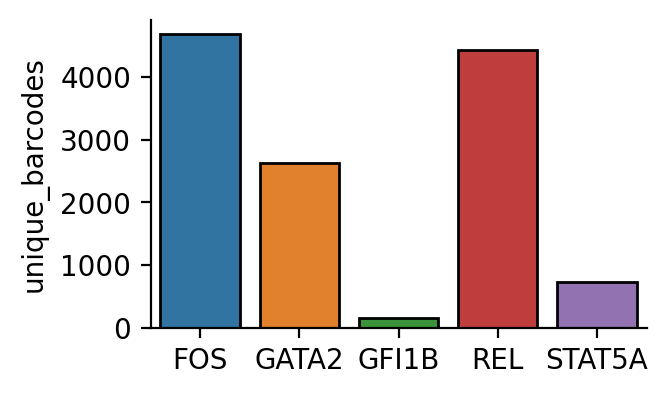

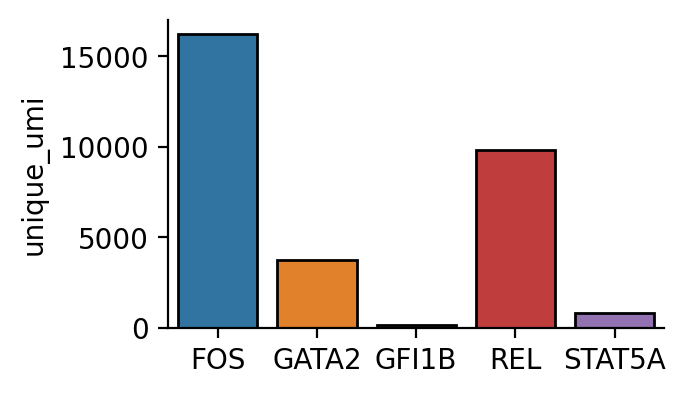

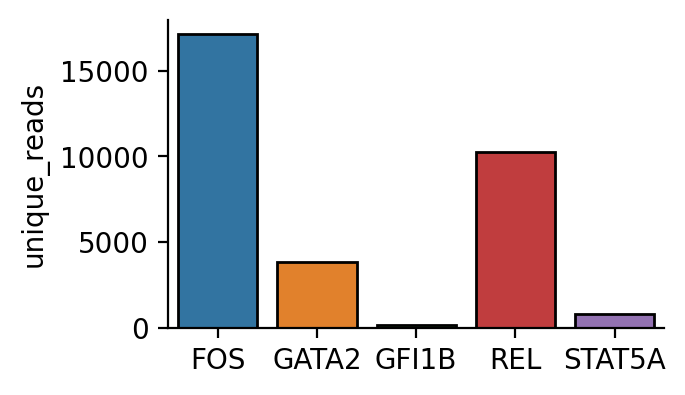

In [6]:
gx = res.groupby('gene_name').agg(
    unique_barcodes = ('barcode', 'nunique'),
    unique_umi = ('umi', 'nunique'),
    unique_reads = ('read_name', 'nunique'),
).reset_index(drop=False)

for col in ['unique_barcodes', 'unique_umi', 'unique_reads']:

    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 3.2, 2
    sns.barplot(data=gx, 
                x='gene_name', 
                y=col,
                # hue='forward',
                ec='k')

    # sns.move_legend(plt.gca(), 
    #                 title='Mapped Forward',
    #                 loc='upper right',
    #                 bbox_to_anchor=(1.1, 1.5))
    plt.xlabel('')
    sns.despine()
    plt.show()

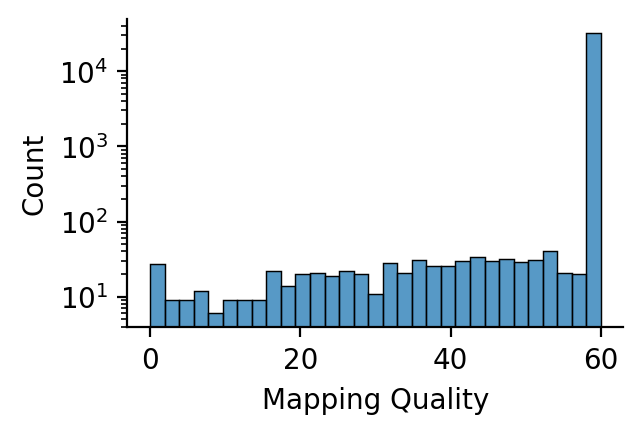

In [7]:
sns.histplot(data=res, 
             x='mapping_quality', 
             multiple='stack',
             bins=31)

plt.xlabel("Mapping Quality")
sns.despine()

plt.yscale('log')

# barcode summary

mat.shape=(30, 6)


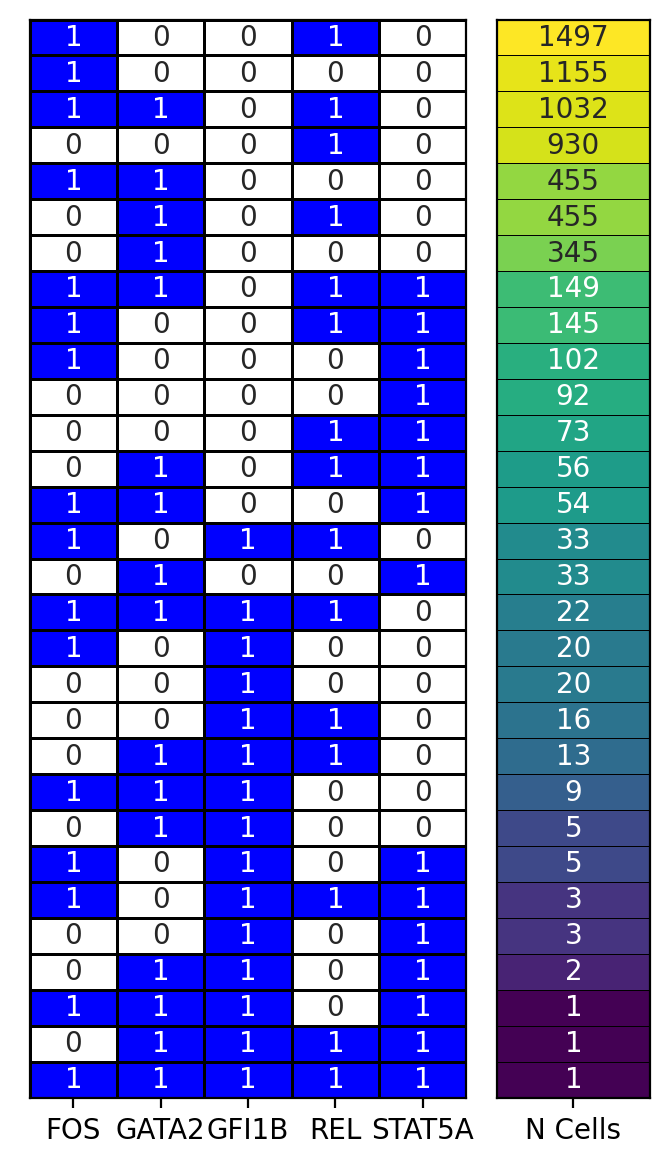

In [8]:
gx = res.groupby(['barcode', 'gene_name']).agg(
    unique_umi = ('umi', 'nunique'),
).reset_index(drop=False)

gx = pd.pivot_table(gx, index='barcode',
                    columns='gene_name',
                    values='unique_umi')
gx = gx.fillna(0)
gx = gx.astype(bool)
columns = list(gx.columns)
gx = gx.reset_index(drop=False)

mat = gx.groupby(columns)['barcode'].count().reset_index(drop=False)
print(f"{mat.shape=}")
mat = mat.sort_values(by='barcode', ascending=False)
mat = mat.rename(columns={'barcode' : 'N Cells'})

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 7

sns.heatmap(mat[columns].astype(int),
            cbar=False,
            annot=True,
            lw=0.5,
            linecolor='k',
            cmap=['w', 'blue'])

ax = plt.gca()
ax.set_yticks([])

divider = make_axes_locatable(ax) 
ax2 = divider.append_axes(position='right', size="35%", pad="7%")

sns.heatmap(mat[['N Cells']],
            cbar=False,
            lw=0.3,
            linecolor='k',
            cmap='viridis',
            fmt=".0f",
            annot=True,
            norm=LogNorm(),
            ax=ax2)

ax2.set_xlabel('')
ax2.set_yticks([])
sns.despine(right=False, 
            bottom=False, 
            left=False,
            top=False)

# write TF reads to file

In [9]:
bam_path = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/alignments/alignments.sorted.bam"
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/10xBarcoded_SingleCell/all_merged/v5_reads/tf_read_ids.txt"
buffer_bp = 1000 # base pair fudge factor

bamfile = pysam.AlignmentFile(bam_path, "rb")

qnames = []
for _, gene_rec in genes.iterrows():
    chrom = gene_rec['Chromosome']
    start = gene_rec['Start'] - buffer_bp
    end = gene_rec['End'] + buffer_bp
    
    for read in bamfile.fetch(chrom, start, end):
        query_name = read.query_name
        
        row = {
            'query_name' : query_name,
        }
        qnames.append(row)
        
qnames = pd.DataFrame(qnames)
qnames.to_csv(outpath, index=False, header=False,)
qnames.head()

,query_name
0,TTACTGTCATTAAGCC_ATCATACTGATA#176f6512-be8e-4c...
1,TGTGAGTAGGCATTTC_AACATTCGAAGG#8080a116-4412-4d...
2,CCGTGAGCAAATCCCA_CACGCACTAAAC#c2615c99-8cf3-4c...
3,CTCACTGCAAATGGAT_CTTTTGTAGGTG#62202ae9-09a6-43...
4,GGTGGCTTCCATCTGC_TTGTATGTACAA#65280854-46e4-4a...


# After extracting reads based on V5 sequence or reads from the above alignments

`seqkit -sp "AGTGGGTTTGGGATTGGCTTTCC, GGAAAGCCAATCCCAAACCCACT" -m 1 -j 36 -o [output] [input] `

and

`seqkit -n -f tf_read_ids.txt -j 36 -o [output] [input] `

results stored in: `/nfs/turbo/umms-indikar/shared/projects/HSC/data/10xBarcoded_SingleCell/all_merged/v5_reads/`

In [10]:
# break

# ID V5 tags 

In [11]:
bam_path = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/alignments/alignments.sorted.bam"
buffer_bp = 1000 # base pair fudge factor

# tag sequences
v5_tags = {
    'V5' : "AGTGGGTTTGGGATTGGCTTTCC", 
    'V5rc' : "GGAAAGCCAATCCCAAACCCACT",
    'HT' : "CACCACCACCACCACCAC",
    'HTrc' : "GTGGTGGTGGTGGTGGTG",
}


bamfile = pysam.AlignmentFile(bam_path, "rb")
res = []
for _, gene_rec in genes.iterrows():
    chrom = gene_rec['Chromosome']
    start = gene_rec['Start'] - buffer_bp
    end = gene_rec['End'] + buffer_bp
    
    for read in bamfile.fetch(chrom, start, end):
        barcode = read.qname.split('_')[0]
        umi = read.qname.split('_')[1].split("#")[0]
        read_name = read.qname.split("#")[1][:-2]
        
        row = {
            'barcode' : barcode,
            'umi' : umi,
            'read_name' : read_name,
            'forward' : read.is_forward,
            'mapping_quality' : read.mapping_quality,
            'gene_name' : gene_rec['gene_name'],
            'query_length' : read.query_length,
        }

        # search for tag in query seq
        # query_seq = read.seq
        query_seq = read.get_forward_sequence()
        # print(query_seq)
    #     break
    # break

        for tag, tag_seq in v5_tags.items():
            row[tag] = tag_seq in query_seq
        
        res.append(row)
        
res = pd.DataFrame(res)
res.head()

,barcode,umi,read_name,forward,mapping_quality,gene_name,query_length,V5,V5rc,HT,HTrc
0,TTACTGTCATTAAGCC,ATCATACTGATA,176f6512-be8e-4cb7-a6d8-0ce381b7b43b,False,60,FOS,924,False,False,False,False
1,TGTGAGTAGGCATTTC,AACATTCGAAGG,8080a116-4412-4da0-bee5-12da276833f3,True,60,FOS,1386,False,False,False,False
2,CCGTGAGCAAATCCCA,CACGCACTAAAC,c2615c99-8cf3-4cce-bc92-4e1a0c35e81d,True,60,FOS,368,False,False,False,False
3,CTCACTGCAAATGGAT,CTTTTGTAGGTG,62202ae9-09a6-436b-9ad5-5c4e4a9da6d8,True,38,FOS,802,False,False,False,False
4,GGTGGCTTCCATCTGC,TTGTATGTACAA,65280854-46e4-4a12-a654-f1aac405d480,False,19,FOS,196,False,False,False,False


In [12]:
for tag, _ in v5_tags.items():
    print(f"\n==== {tag.upper()} SUMMARY ====")

    print(res[tag].value_counts())


==== V5 SUMMARY ====
False    32322
True        53
Name: V5, dtype: int64

==== V5RC SUMMARY ====
False    32290
True        85
Name: V5rc, dtype: int64

==== HT SUMMARY ====
False    32323
True        52
Name: HT, dtype: int64

==== HTRC SUMMARY ====
False    32346
True        29
Name: HTrc, dtype: int64


In [13]:
for v5 in ['V5', 'V5rc']:
    for ht in ['HT', 'HTrc']:
        n = res[res[v5] & res[ht]].shape[0]
        print(f"{v5} {ht} {n=}")

V5 HT n=0
V5 HTrc n=20
V5rc HT n=46
V5rc HTrc n=0


has_tag
False    6727
True       66
Name: barcode, dtype: int64


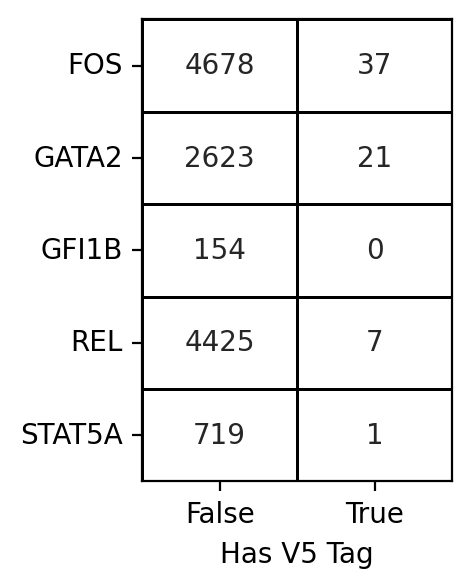

In [14]:
gx = res.copy()
gx['has_tag'] = (gx['V5'] & gx['HTrc']) | (gx['V5rc'] & gx['HT'])

print(gx.groupby(['has_tag',])['barcode'].nunique())

groupers = ['gene_name', 'has_tag']
gx = gx.groupby(groupers)['barcode'].nunique().reset_index()

gx = pd.pivot_table(gx, 
                    index='gene_name',
                    columns='has_tag',
                    values='barcode')
gx = gx.fillna(0)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2, 3
sns.heatmap(gx,
            annot=True,
            lw=1,
            linecolor='k',
            cbar=False,
            fmt=".0f",
            cmap=['w'])

plt.ylabel("")
plt.xlabel("Has V5 Tag")
plt.gca().tick_params(axis='y', rotation=0)
sns.despine(right=False, 
            bottom=False, 
            left=False,
            top=False)

# Check FASTQ files

check the fastq files for V5 tags

In [15]:
bam_path = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/alignments/alignments.sorted.bam"
buffer_bp = 1000 # base pair fudge factor

bamfile = pysam.AlignmentFile(bam_path, "rb")

qnames = []
for _, gene_rec in genes.iterrows():
    chrom = gene_rec['Chromosome']
    start = gene_rec['Start'] - buffer_bp
    end = gene_rec['End'] + buffer_bp
    
    for read in bamfile.fetch(chrom, start, end):
        query_name = read.query_name
        barcode = read.qname.split('_')[0]
        umi = read.qname.split('_')[1].split("#")[0]
        read_name = read.qname.split("#")[1][:-2]
        
        row = {
            'read_name' : query_name,
            'gene_name' : gene_rec['gene_name'],
            'barcode' : barcode,
            'umi' : umi,
        }
        qnames.append(row)
        
qnames = pd.DataFrame(qnames)
qnames = qnames.drop_duplicates()
qnames = qnames.set_index('read_name')
read_mapper = qnames.to_dict(orient='index')
qnames.head()

,gene_name,barcode,umi
read_name,,,
TTACTGTCATTAAGCC_ATCATACTGATA#176f6512-be8e-4cb7-a6d8-0ce381b7b43b_+,FOS,TTACTGTCATTAAGCC,ATCATACTGATA
TGTGAGTAGGCATTTC_AACATTCGAAGG#8080a116-4412-4da0-bee5-12da276833f3_+,FOS,TGTGAGTAGGCATTTC,AACATTCGAAGG
CCGTGAGCAAATCCCA_CACGCACTAAAC#c2615c99-8cf3-4cce-bc92-4e1a0c35e81d_+,FOS,CCGTGAGCAAATCCCA,CACGCACTAAAC
CTCACTGCAAATGGAT_CTTTTGTAGGTG#62202ae9-09a6-436b-9ad5-5c4e4a9da6d8_+,FOS,CTCACTGCAAATGGAT,CTTTTGTAGGTG
GGTGGCTTCCATCTGC_TTGTATGTACAA#65280854-46e4-4a12-a654-f1aac405d480_-,FOS,GGTGGCTTCCATCTGC,TTGTATGTACAA


In [16]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/10xBarcoded_SingleCell/all_merged/v5_reads/matched_ids.fastq"

res = []


fastq = pysam.FastxFile(fpath)

for read in fastq:
    gene_name = read_mapper[read.name]['gene_name']
    barcode = read_mapper[read.name]['barcode']
    umi = read_mapper[read.name]['umi']

    read_seq = read.sequence
    
    row = {
        'barcode' : barcode,
        'umi' : umi,
        'gene_name' : gene_name,
        'read_len' : len(read_seq),
    }

    for tag, tag_seq in v5_tags.items():
        row[tag] = tag_seq in read_seq
        
    res.append(row)
    
res = pd.DataFrame(res)
res.head()

,barcode,umi,gene_name,read_len,V5,V5rc,HT,HTrc
0,TCTTTGATCCATGCAA,CCATCCAAGATA,FOS,638,False,False,False,False
1,AAGGTAAAGCCTGCCA,TGTTCTCCGATG,FOS,571,False,False,False,False
2,TCTACATGTAGCTAAA,TAGTATTACGGA,GATA2,712,False,False,False,False
3,TCCTCGACAACTGAAA,CGTGAATTGGTC,REL,422,False,False,False,False
4,AAGGAATGTAAGGCTG,CATCCTCATATT,FOS,559,False,False,False,False


In [17]:
for tag, _ in v5_tags.items():
    print(f"\n==== {tag.upper()} SUMMARY ====")

    print(res[tag].value_counts())


==== V5 SUMMARY ====
False    32136
True        68
Name: V5, dtype: int64

==== V5RC SUMMARY ====
False    32081
True       123
Name: V5rc, dtype: int64

==== HT SUMMARY ====
False    32112
True        92
Name: HT, dtype: int64

==== HTRC SUMMARY ====
False    32155
True        49
Name: HTrc, dtype: int64


In [18]:
for v5 in ['V5', 'V5rc']:
    for ht in ['HT', 'HTrc']:
        n = res[res[v5] & res[ht]].shape[0]
        print(f"{v5} {ht} {n=}")

V5 HT n=0
V5 HTrc n=35
V5rc HT n=82
V5rc HTrc n=0


has_tag
False    6725
True      115
Name: barcode, dtype: int64


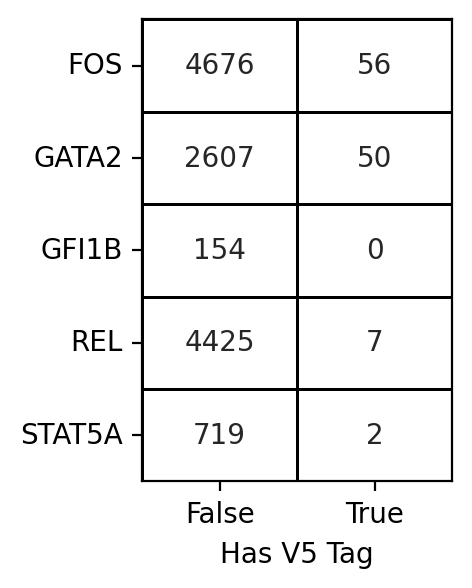

In [19]:
gx = res.copy()
gx['has_tag'] = (gx['V5'] & gx['HTrc']) | (gx['V5rc'] & gx['HT'])

print(gx.groupby(['has_tag',])['barcode'].nunique())

groupers = ['gene_name', 'has_tag']
gx = gx.groupby(groupers)['barcode'].nunique().reset_index()

gx = pd.pivot_table(gx, 
                    index='gene_name',
                    columns='has_tag',
                    values='barcode')
gx = gx.fillna(0)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2, 3
sns.heatmap(gx,
            annot=True,
            lw=1,
            linecolor='k',
            cbar=False,
            fmt=".0f",
            cmap=['w'])

plt.ylabel("")
plt.xlabel("Has V5 Tag")
plt.gca().tick_params(axis='y', rotation=0)
sns.despine(right=False, 
            bottom=False, 
            left=False,
            top=False)

# Load single-cell data

In [20]:
fpath = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/scanpy/anndata_distance.h5ad"

adata = sc.read_h5ad(fpath)
adata.obs['cluster_name'] = adata.obs['clusters'].apply(lambda x: f"C{int(x) + 1}")
adata

AnnData object with n_obs × n_vars = 8475 × 14753
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'clusters', 'cluster_name', 'UMAP 1', 'UMAP 2', 'Fibroblast_mean', 'Fibroblast_max', 'Fibroblast_argmax', 'Fibroblast_highest_exp', 'HSC_mean', 'HSC_max', 'HSC_argmax', 'HSC_highest_exp'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_name_colors', 'clusters_colors', 'clusters_sizes', 'dendrogram_cluster_name', 'hvg', 'leiden', 'log1p', 'neighbors', 'paga', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

# merge V5 positive reads

In [21]:
""" Load the single cell data"""
fpath = "/scratch/indikar_root/indikar1/cstansbu/all_HSC/scanpy/anndata_distance.h5ad"
adata = sc.read_h5ad(fpath)
adata.obs['cluster_name'] = adata.obs['clusters'].apply(lambda x: f"C{int(x) + 1}")


"""Structure the v5 tag results """
gx = res.copy()
gx['has_tag'] = (gx['V5'] & gx['HTrc']) | (gx['V5rc'] & gx['HT'])
gx = gx[gx['has_tag']]
print(f"{gx.shape=}")

gx = gx[['barcode', 'gene_name']].drop_duplicates()
gx['val'] = True
gx = pd.pivot_table(gx, 
                    index='barcode', 
                    columns='gene_name',
                    values='val')

gx = gx.fillna(0)
v5_columns = [f"{x}_v5" for x in gx.columns]
gx.columns = v5_columns

"""Lastly, drop barcodes not present in the single-cell data """
gx = gx[gx.index.isin(adata.obs.index)]
print(f"{gx.shape=}")

"""merge """
adata.obs = pd.merge(adata.obs, gx, 
                     how='left',
                     left_index=True,
                     right_index=True)

adata.obs[v5_columns] = adata.obs[v5_columns].fillna(0)

adata.obs['has_tag'] = adata.obs[v5_columns].astype(bool).sum(axis=1)

print()
print(adata.obs['has_tag'].value_counts())

print()
adata

gx.shape=(117, 9)
gx.shape=(115, 4)

0    8360
1     115
Name: has_tag, dtype: int64



AnnData object with n_obs × n_vars = 8475 × 14753
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'clusters', 'cluster_name', 'UMAP 1', 'UMAP 2', 'Fibroblast_mean', 'Fibroblast_max', 'Fibroblast_argmax', 'Fibroblast_highest_exp', 'HSC_mean', 'HSC_max', 'HSC_argmax', 'HSC_highest_exp', 'FOS_v5', 'GATA2_v5', 'REL_v5', 'STAT5A_v5', 'has_tag'
    var: 'gene_name', 'Chromosome', 'Start', 'End', 'Strand', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cluster_name_colors', 'clusters_colors', 'clusters_sizes', 'dendrogram_cluster_name', 'hvg', 'leiden', 'log1p', 'neighbors', 'paga', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

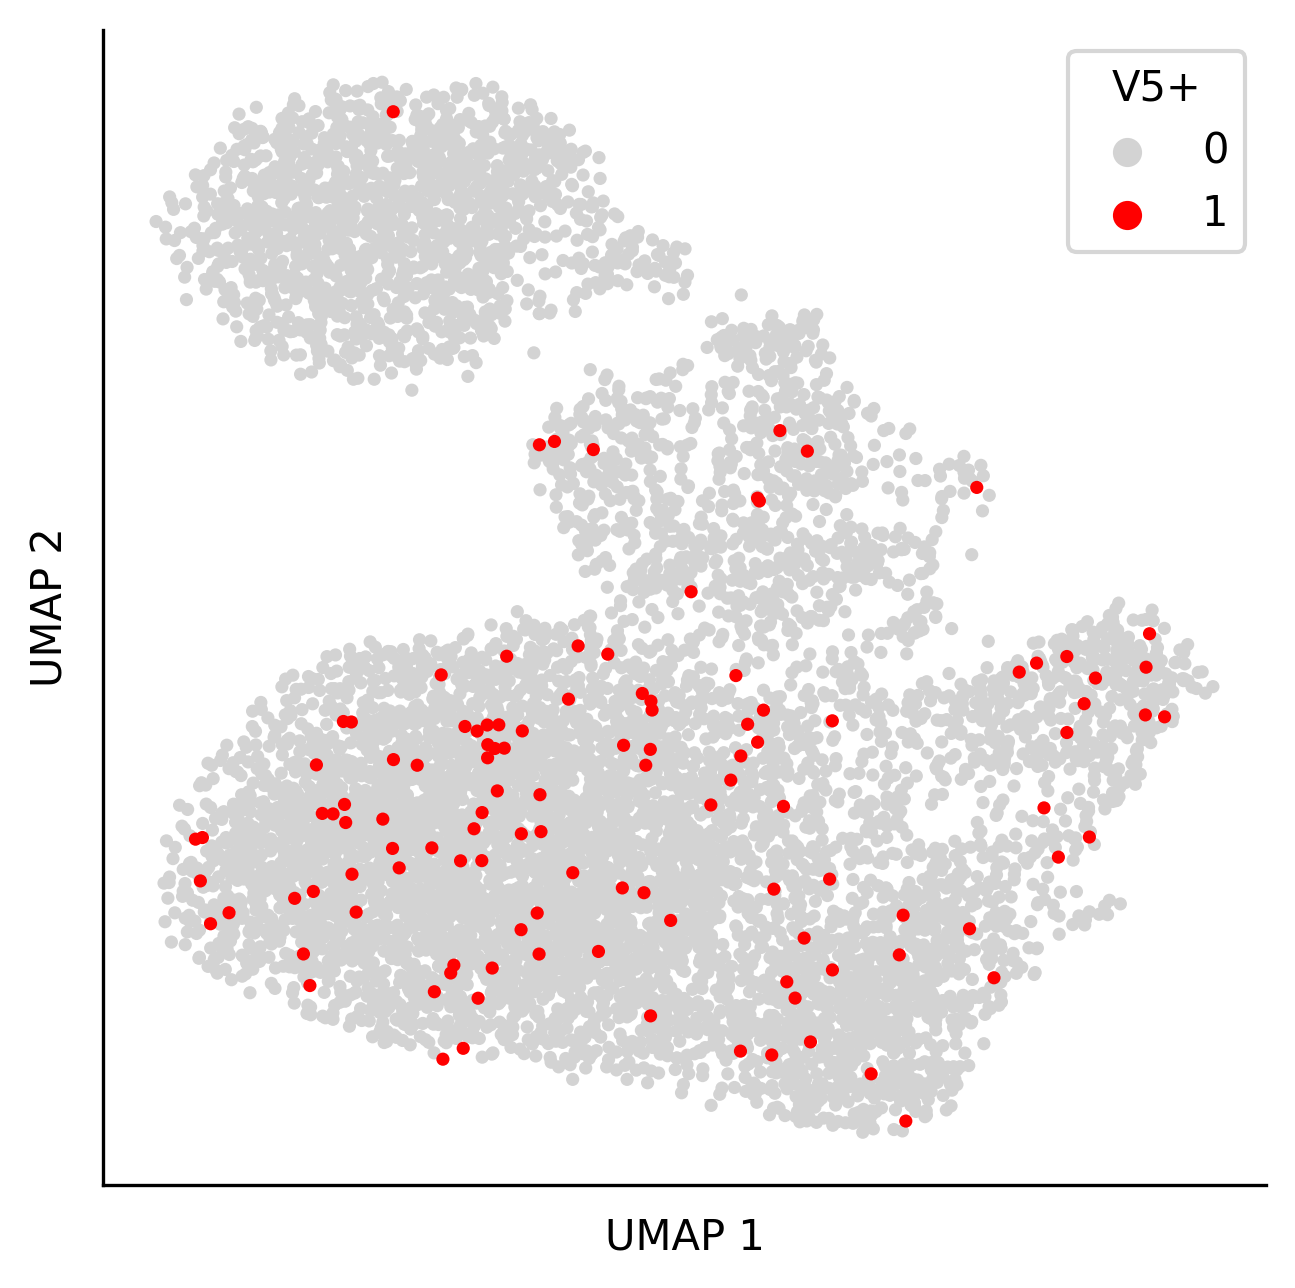

In [22]:
""" Plot it """
pdf = adata.obs.copy()
order = np.argsort(pdf['has_tag'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(data=pdf.iloc[order], 
                x='UMAP 1',
                y='UMAP 2',
                hue='has_tag',
                ec='none',
                palette=['lightgrey', 'r'],
                s=10)

plt.yticks([])
plt.xticks([])
plt.ylabel("UMAP 2")
plt.xlabel("UMAP 1")
sns.despine()

sns.move_legend(plt.gca(),
                loc='upper right',
                title="V5+")

In [23]:
pdf = adata.obs.copy()

# filter just the positive cells
pdf = pdf[pdf['has_tag'] == 1]
print(f"{pdf.shape=}")

for tf_tag in v5_columns:
    print(f"\n==== {tf_tag.upper()} SUMMARY ====")
    gx = pdf[pdf[tf_tag] == 1]

    print(f"Mean expression of FB markers: {gx['Fibroblast_mean'].mean():.3f}")
    print(f"Mean expression of HSC markers: {gx['HSC_mean'].mean():.3f}")
    
    print(gx['cluster_name'].value_counts().to_string())
    
pdf.head()

pdf.shape=(115, 22)

==== FOS_V5 SUMMARY ====
Mean expression of FB markers: 0.236
Mean expression of HSC markers: 0.153
C1    39
C4     9
C3     8
C2     0

==== GATA2_V5 SUMMARY ====
Mean expression of FB markers: 0.243
Mean expression of HSC markers: 0.156
C1    45
C4     4
C3     1
C2     0

==== REL_V5 SUMMARY ====
Mean expression of FB markers: 0.240
Mean expression of HSC markers: 0.157
C1    7
C2    0
C3    0
C4    0

==== STAT5A_V5 SUMMARY ====
Mean expression of FB markers: 0.231
Mean expression of HSC markers: 0.254
C1    1
C2    1
C3    0
C4    0


,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,clusters,cluster_name,UMAP 1,UMAP 2,Fibroblast_mean,...,Fibroblast_highest_exp,HSC_mean,HSC_max,HSC_argmax,HSC_highest_exp,FOS_v5,GATA2_v5,REL_v5,STAT5A_v5,has_tag
cell_id,,,,,,,,,,,,,,,,,,,,,
AAACGCTTCACTCCGT,2353,2353,7670,0,0.0,0,C1,3.374739,-2.507601,0.262896,...,KLF2,0.141051,0.834552,5,PTPRC,1.0,0.0,0.0,0.0,1
AACAAAGGTACTAGCT,1870,1870,4399,0,0.0,0,C1,7.612252,2.700264,0.227351,...,KLF2,0.145875,2.056650,3,MPL,1.0,0.0,0.0,0.0,1
AACTTCTAGCTACGTT,1151,1151,2499,0,0.0,0,C1,2.493515,-3.493710,0.216222,...,KLF2,0.045345,1.609758,13,MEIS1,0.0,1.0,0.0,0.0,1
AAGACAAGTACAGGTG,1941,1941,6341,0,0.0,0,C1,3.347582,-1.591985,0.297838,...,KLF2,0.140054,1.424090,68,DNMT3B,0.0,1.0,0.0,0.0,1
AATCACGCAACTCGAT,2269,2269,8129,0,0.0,3,C4,10.878349,-0.343384,0.246840,...,KLF2,0.097639,1.241363,3,MPL,1.0,0.0,0.0,0.0,1


In [46]:
pos = adata[adata.obs['has_tag'] == 1]
neg = adata[adata.obs['has_tag'] == 0]

pos_df = pos.to_df(layer='counts')
neg_df = neg.to_df(layer='counts')
pos_df.columns = pos.var['gene_name'].to_list()
neg_df.columns = neg.var['gene_name'].to_list()
pos_df[TFs].head()

,GATA2,GFI1B,FOS,STAT5A,REL
cell_id,,,,,
AAACGCTTCACTCCGT,1,0,0,0,0
AACAAAGGTACTAGCT,1,0,0,0,0
AACTTCTAGCTACGTT,0,0,0,0,0
AAGACAAGTACAGGTG,0,0,0,0,0
AATCACGCAACTCGAT,0,0,0,0,0


In [49]:
print(pos_df[TFs].sum(axis=0))
print()
print(neg_df[TFs].sum(axis=0))
print()

GATA2     27
GFI1B     10
FOS        4
STAT5A     7
REL        4
dtype: int64

GATA2     1298
GFI1B      680
FOS        486
STAT5A     328
REL        354
dtype: int64



In [50]:
print(pos.obs[['Fibroblast_mean', 'HSC_mean']].mean())
print()
print(pos.obs[['Fibroblast_mean', 'HSC_mean']].mean())

Fibroblast_mean    0.239427
HSC_mean           0.156233
dtype: float32